# 03 Modeling: results of the training runs

This notebook reads the results of `python -m src.models.train` from the MLflow tracking database (`mlflow.db`).
It does not retrain anything. Run the training script first.

**What was trained:** a majority-class baseline, logistic regression, random forest and XGBoost, on the 9,773 records
from the four WPdx sources with mixed labels. Each model was tuned with 5-fold stratified cross-validation on macro F1.
The best model was chosen on the cross-validation score, never on the test set.

In [1]:
# Run from the repo root folder, or this cell moves there for you
import os, sys
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, str(Path.cwd()))
os.environ["MLFLOW_DISABLE_AGENT_HINT"] = "1"
import warnings; warnings.filterwarnings("ignore")

In [2]:
import mlflow, json, pandas as pd
from src.models.config import MLFLOW_URI, EXPERIMENT
mlflow.set_tracking_uri(MLFLOW_URI)
runs = mlflow.search_runs(experiment_names=[EXPERIMENT], filter_string="tags.mlflow.parentRunId IS NULL")
cols = {"tags.mlflow.runName": "run", "metrics.cv_macro_f1_mean": "cv_macro_f1",
        "metrics.test_macro_f1": "test_macro_f1", "metrics.test_balanced_accuracy": "test_balanced_accuracy",
        "metrics.test_recall_non_functional": "test_recall_non_functional",
        "metrics.test_roc_auc_ovr_macro": "test_roc_auc"}
runs[list(cols)].rename(columns=cols).round(3)

,run,cv_macro_f1,test_macro_f1,test_balanced_accuracy,test_recall_non_functional,test_roc_auc
0,comparison_all_sources,NaN,NaN,NaN,NaN,NaN
1,ablation_random_forest_with_location,NaN,0.584,0.592,0.404,0.788
2,xgboost,0.540,0.543,0.581,0.473,0.760
3,random_forest,0.547,0.562,0.567,0.376,0.774
4,logistic_regression,0.428,0.427,0.521,0.442,0.700
5,baseline_majority,NaN,0.272,0.333,0.000,0.500


## Selected model, tuned settings and operating point

In [3]:
s = json.load(open("reports/metrics/training_summary.json"))
best = s["selected_model"]
print("Selected:", best, "| registered version", s["registered_version"])
print("Best settings:", s["results"][best]["best_params"])
print("Operating point for Non-Functional:", s["results"][best]["operating_point"])
print(open(f"reports/metrics/classification_report_{best}.txt").read())

Selected: random_forest | registered version 1
Best settings: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 5, 'clf__max_features': 0.3, 'clf__max_depth': None}
Operating point for Non-Functional: {'nf_threshold': 0.27, 'test_nf_recall': 0.6865203761755486, 'test_nf_precision': 0.27238805970149255, 'test_share_flagged': 0.4112531969309463}
                precision    recall  f1-score   support

    Functional      0.814     0.803     0.808      1344
  Needs Repair      0.463     0.521     0.490       292
Non-Functional      0.399     0.376     0.387       319

      accuracy                          0.691      1955
     macro avg      0.559     0.567     0.562      1955
  weighted avg      0.694     0.691     0.692      1955



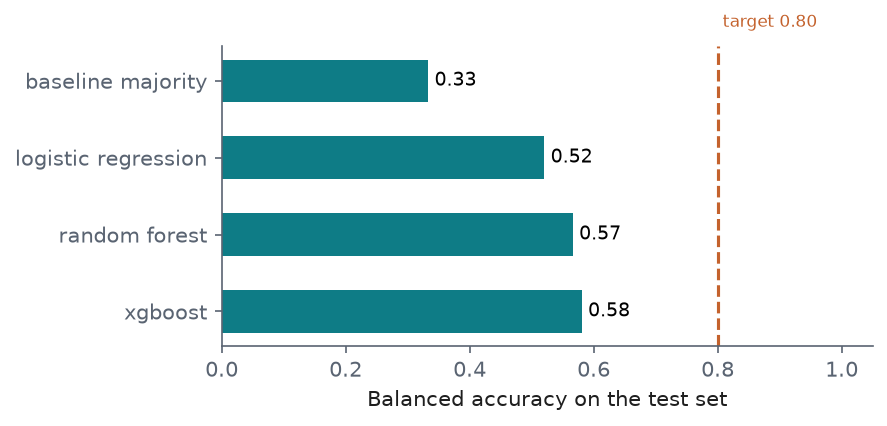

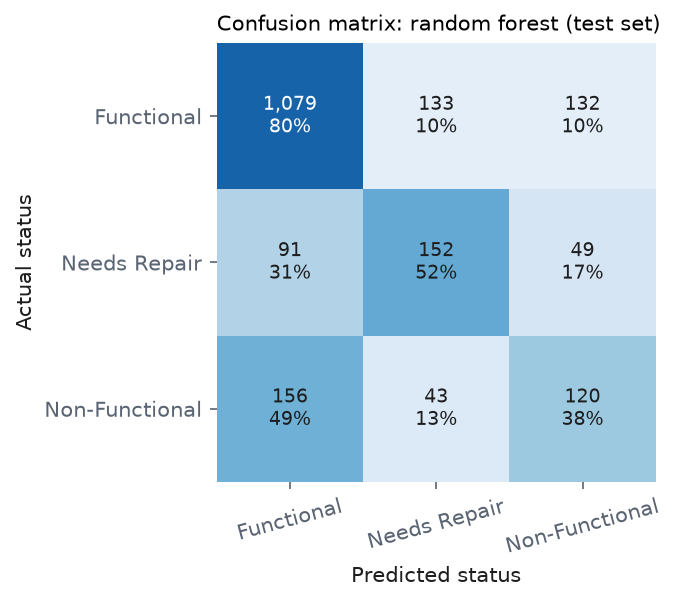

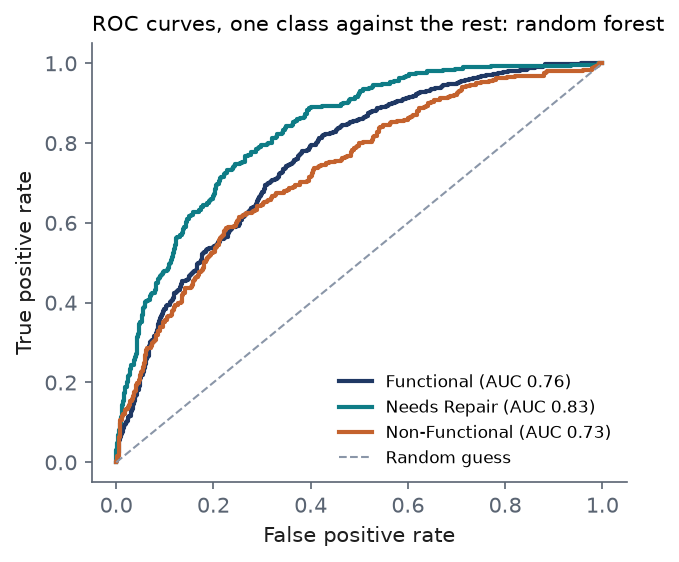

In [4]:
from IPython.display import Image, display
for f in ["model_comparison_balanced_accuracy", f"confusion_{best}", "roc_best_model"]:
    display(Image(f"reports/figures/{f}.png"))

## Comparison: the same model trained on all 16 sources

In [5]:
c = s["results"]["comparison_all_sources"]
pd.DataFrame({"tested on all sources": c["test_all"], "tested on mixed-label sources only": c["test_mixed_only"]}).loc[
    ["macro_f1", "balanced_accuracy", "recall_non_functional"]].round(3)

,tested on all sources,tested on mixed-label sources only
macro_f1,0.742,0.458
balanced_accuracy,0.767,0.489
recall_non_functional,0.865,0.031


The all-sources model scores higher overall because 12 of the 16 sources label every record Non-Functional,
and the model learns to recognise those surveys. On the records with real label variation it does worse than the
selected model. That is why the selected model is trained on the mixed-label sources only.